# Segmentación de instancias con YOLO: placas, vehículos y personas

En el tutorial anterior entrenamos un detector que encuentra placas y dibuja una **caja** alrededor de cada una. Una caja es útil, pero es una aproximación: incluye pedazos de fondo y no sigue la forma real del objeto.

La **segmentación** va un paso más allá: el modelo dice, **píxel por píxel**, qué parte de la imagen pertenece a cada objeto. El resultado es una **máscara**.

| Tarea | Pregunta que responde | Salida |
|-------|----------------------|--------|
| Clasificación | ¿Qué hay en la imagen? | Una etiqueta por imagen |
| Detección | ¿Qué hay y dónde está? | Una caja + clase + confianza por objeto |
| **Segmentación** | **¿Qué píxeles pertenecen a cada objeto?** | **Una máscara + clase + confianza por objeto** |

En este tutorial entrenaremos un modelo que segmenta **placas, vehículos, motos y personas** en las mismas fotos del dataset de placas.

### Tipos de segmentación

- **Semántica:** pinta cada píxel con su clase ("esto es vehículo"), pero no separa un auto de otro.
- **De instancias:** separa cada objeto: "vehículo 1", "vehículo 2"... Es lo que hace YOLO y lo que haremos aquí.
- **Panóptica:** combina las dos (objetos separados + fondo clasificado).

### Plan del notebook

1. Entender qué es una **máscara** con un modelo preentrenado.
2. Resolver un problema real: nuestro dataset **solo tiene cajas**, no máscaras.
3. Generar las máscaras automáticamente con **SAM** (placas) y un modelo de COCO (las demás clases).
4. **Entrenar** un modelo `yolo26n-seg` con las 4 clases.
5. **Evaluar**: IoU de máscaras y mAP de máscaras.
6. Una aplicación práctica: **anonimizar placas** y **recortar vehículos**.

## 1. Preparación del entorno

Usamos la misma librería que en detección, **Ultralytics**, que también incluye modelos de segmentación y el modelo **SAM**. Si no está instalada:

```bash
uv add ultralytics
```

Las rutas:

- `DATA_DIR`: el dataset original de placas (solo cajas).
- `SEG_DIR`: el **nuevo** dataset de segmentación que vamos a construir en este notebook.
- `RUNS_DIR`: donde se guardan los entrenamientos. Como en el tutorial de detección, las rutas son **absolutas** para que Ultralytics no las guarde en su carpeta global.

In [1]:
from pathlib import Path
import random
import shutil
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from PIL import Image, ImageDraw, ImageFilter

import ultralytics
from ultralytics import SAM, YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    DEVICE = 0              # primera GPU NVIDIA
elif torch.backends.mps.is_available():
    DEVICE = "mps"          # GPU de Apple (M1/M2/M3...)
else:
    DEVICE = "cpu"

warnings.filterwarnings("ignore", message=".*does not have a deterministic implementation.*")

DATA_DIR = Path("../data/license-plates").resolve()        # dataset original (cajas)
SEG_DIR = Path("../data/license-plates-seg").resolve()     # dataset de segmentación (lo creamos aquí)
RUNS_DIR = Path("runs").resolve()

print(f"Ultralytics {ultralytics.__version__} | PyTorch {torch.__version__} | Dispositivo: {DEVICE}")

Ultralytics 8.4.170 | PyTorch 2.14.0+cu132 | Dispositivo: 0


Funciones auxiliares que usaremos en todo el notebook:

- `mostrar()`: muestra una imagen con matplotlib (la misma del tutorial de detección).
- `caja_real()`: lee la caja de la placa desde el `.txt` del dataset original y la devuelve en píxeles.
- `poligono_a_mascara()`: convierte un polígono en una **máscara**: una matriz del tamaño de la imagen con `True` dentro del objeto y `False` fuera.

In [2]:
def mostrar(imagen, titulo=None, ax=None, figsize=(8, 6)):
    # Muestra una imagen (ruta, PIL o arreglo RGB) con matplotlib.
    if isinstance(imagen, (str, Path)):
        imagen = Image.open(imagen)
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    ax.imshow(imagen)
    ax.axis("off")
    if titulo:
        ax.set_title(titulo, fontsize=10)
    return ax


def caja_real(ruta_img):
    # Cajas de placa del dataset original, en píxeles (x1, y1, x2, y2). Una fila por placa.
    ruta_img = Path(ruta_img)
    ancho, alto = Image.open(ruta_img).size
    etiquetas = np.loadtxt(DATA_DIR / "labels" / ruta_img.parent.name / f"{ruta_img.stem}.txt", ndmin=2)
    xc, yc, w, h = etiquetas[:, 1], etiquetas[:, 2], etiquetas[:, 3], etiquetas[:, 4]
    return np.stack([(xc - w / 2) * ancho, (yc - h / 2) * alto, (xc + w / 2) * ancho, (yc + h / 2) * alto], axis=1)


def poligono_a_mascara(poligono, ancho, alto):
    # Polígono en píxeles [[x, y], ...] → máscara booleana de tamaño (alto, ancho).
    lienzo = Image.new("L", (ancho, alto), 0)
    ImageDraw.Draw(lienzo).polygon([tuple(p) for p in poligono], fill=1)
    return np.array(lienzo, dtype=bool)


imgs_train = sorted((DATA_DIR / "images" / "train").glob("*.jpg"))
imgs_val = sorted((DATA_DIR / "images" / "val").glob("*.jpg"))
print(f"Imágenes: {len(imgs_train)} de entrenamiento | {len(imgs_val)} de validación")

Imágenes: 1526 de entrenamiento | 169 de validación


## 2. ¿Qué es una máscara?

Empecemos con un modelo **ya entrenado**: `yolo26n-seg`, la versión de segmentación de YOLO26, entrenada con **COCO** (80 clases de objetos cotidianos). Por dentro es el mismo detector que ya conocemos, con una "cabeza" extra que dibuja la máscara de cada objeto.

El resultado de `predict()` tiene lo mismo que en detección (`resultado.boxes`) **más** las máscaras (`resultado.masks`):

| Atributo | Qué contiene |
|----------|-------------|
| `boxes.xyxy`, `boxes.cls`, `boxes.conf` | Caja, clase y confianza de cada objeto (igual que en detección) |
| `masks.data` | Las máscaras como matrices de 0 y 1, una por objeto |
| `masks.xy` | Cada máscara como **polígono** (lista de puntos del contorno) en píxeles |
| `masks.xyn` | El mismo polígono, **normalizado** entre 0 y 1 |

In [3]:
modelo_coco = YOLO("yolo26n-seg.pt")     # se descarga la primera vez

ruta_ejemplo = imgs_val[0]
resultado = modelo_coco.predict(ruta_ejemplo, conf=0.5, device=DEVICE, verbose=False)[0]

print(f"Objetos encontrados: {len(resultado.boxes)}")
print("Clases:", [resultado.names[int(c)] for c in resultado.boxes.cls])
print(f"masks.data: {tuple(resultado.masks.data.shape)}  ← [objetos, alto, ancho] a la resolución de la red")
print(f"Polígono del primer objeto: {len(resultado.masks.xy[0])} puntos, por ejemplo {resultado.masks.xy[0][0].round(1)}")

Objetos encontrados: 2
Clases: ['car', 'person']
masks.data: (2, 512, 640)  ← [objetos, alto, ancho] a la resolución de la red
Polígono del primer objeto: 600 puntos, por ejemplo [      391.3       101.2]


Veamos la máscara del primer objeto como lo que es: una **matriz de 0 y 1**. La convertimos a la resolución original con `poligono_a_mascara()` y la comparamos con la imagen.

Máscara: forma (452, 678), tipo bool
Píxeles del objeto: 5,456 de 306,456 (1.8% de la imagen)


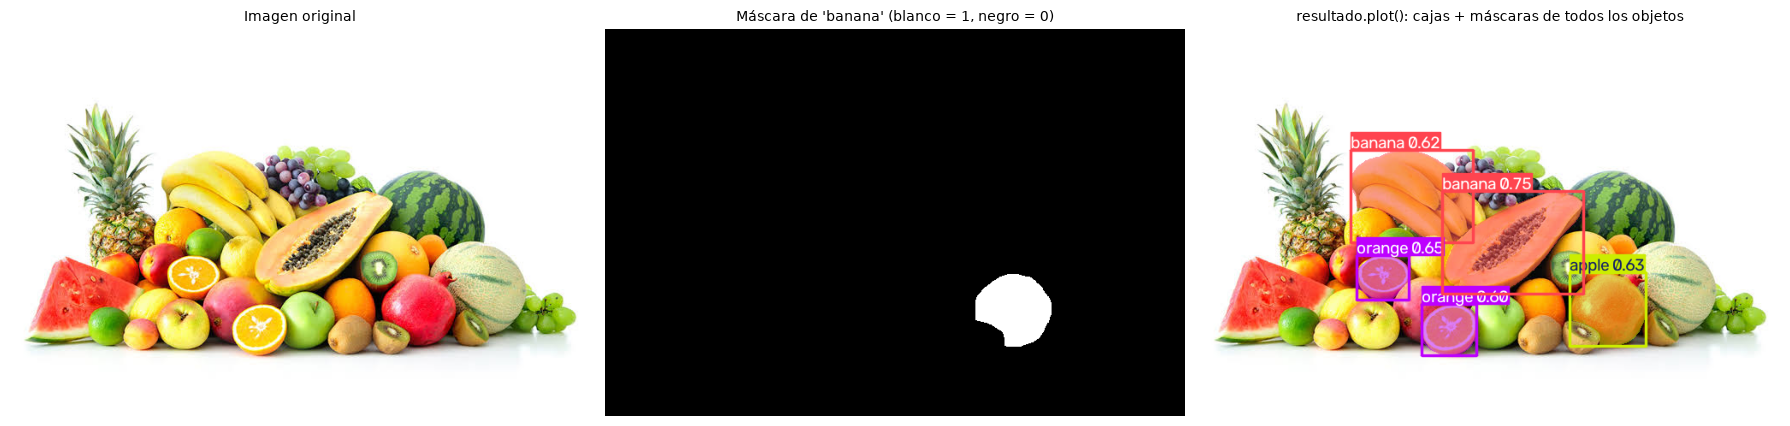

In [4]:
ruta_ejemplo = r"C:\Users\SpideGamer\Documents\ciencia-de-datos-g8\01-python-intro\data\frutas.jpeg"
resultado = modelo_coco.predict(ruta_ejemplo, conf=0.5, device=DEVICE, verbose=False)[0]


ancho, alto = Image.open(ruta_ejemplo).size
mascara = poligono_a_mascara(resultado.masks.xy[2], ancho, alto)
nombre = resultado.names[int(resultado.boxes.cls[0])]

print(f"Máscara: forma {mascara.shape}, tipo {mascara.dtype}")
print(f"Píxeles del objeto: {mascara.sum():,} de {mascara.size:,} ({mascara.mean():.1%} de la imagen)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
mostrar(ruta_ejemplo, "Imagen original", ax=axes[0])
axes[1].imshow(mascara, cmap="gray")
axes[1].set_title(f"Máscara de '{nombre}' (blanco = 1, negro = 0)", fontsize=10)
axes[1].axis("off")
mostrar(resultado.plot()[..., ::-1], "resultado.plot(): cajas + máscaras de todos los objetos", ax=axes[2])
plt.tight_layout()
plt.show()

### ¿Qué observamos?

- La máscara es una imagen en **blanco y negro** del mismo tamaño que la foto: blanco donde está el objeto, negro en el resto.
- Con ella podemos contar **cuántos píxeles** ocupa el objeto, recortarlo sin fondo o modificar solo esa zona (lo haremos al final).
- `resultado.plot()` dibuja las cajas **y** colorea cada máscara. Como en detección, devuelve la imagen en formato BGR, así que invertimos los canales con `[..., ::-1]`.

## 3. El modelo de COCO sobre nuestras fotos

Probemos el modelo preentrenado en varias imágenes del dataset de placas:

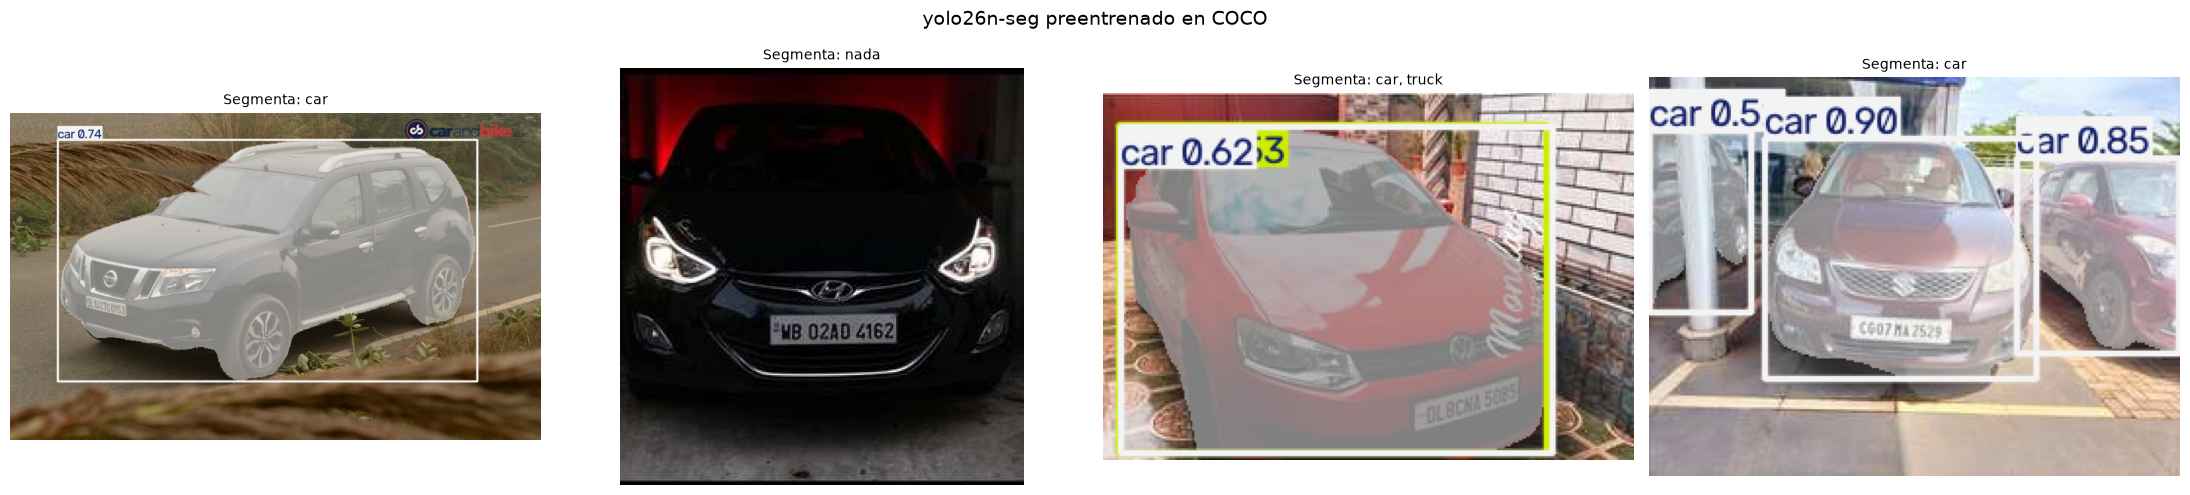

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, ruta in zip(axes, random.sample(imgs_train, 4)):
    resultado = modelo_coco.predict(ruta, conf=0.5, device=DEVICE, verbose=False)[0]
    clases = sorted({resultado.names[int(c)] for c in resultado.boxes.cls}) or ["nada"]
    mostrar(resultado.plot()[..., ::-1], "Segmenta: " + ", ".join(clases), ax=ax)
plt.suptitle("yolo26n-seg preentrenado en COCO", fontsize=14)
plt.tight_layout()
plt.show()

El modelo segmenta muy bien **autos, camiones, motos y personas**, pero, igual que en detección, **no conoce las placas**.

Aquí aparece un problema nuevo: para entrenar un modelo de segmentación necesitamos **máscaras** de ejemplo, y nuestro dataset **solo tiene cajas**. Dibujar el contorno de cada objeto a mano es lento: en herramientas de anotación, un polígono toma entre 30 segundos y un par de minutos por objeto. Para ~1,700 imágenes con varios objetos cada una, serían días de trabajo.

La solución que usaremos: **auto-etiquetado**. Dejaremos que dos modelos ya entrenados dibujen las máscaras por nosotros:

| Clase | ¿De dónde sale la máscara? |
|-------|----------------------------|
| `license_plate` | **SAM**, usando como guía la caja **real** de la placa (anotada por una persona) |
| `vehicle`, `motorcycle`, `person` | Un modelo YOLO de segmentación entrenado en COCO (el "profesor") |

## 4. SAM: segmentar cualquier cosa

**SAM** (*Segment Anything Model*, Meta, 2023) es un modelo entrenado con más de mil millones de máscaras. No conoce clases: su especialidad es **dibujar el contorno** de lo que le señalemos. Se le da una pista (*prompt*):

- un **punto** sobre el objeto, o
- una **caja** alrededor del objeto.

y devuelve la máscara de ese objeto. Es perfecto para nuestro caso: **ya tenemos las cajas** de las placas, anotadas por personas. SAM convierte cada caja en una máscara precisa.

Usaremos `sam2.1_t.pt` (SAM 2.1 *tiny*), la versión más liviana. Probémoslo con una imagen donde la placa está **inclinada**:

Área de la caja:    1,806 píxeles
Área de la máscara: 1,683 píxeles (93% de la caja)


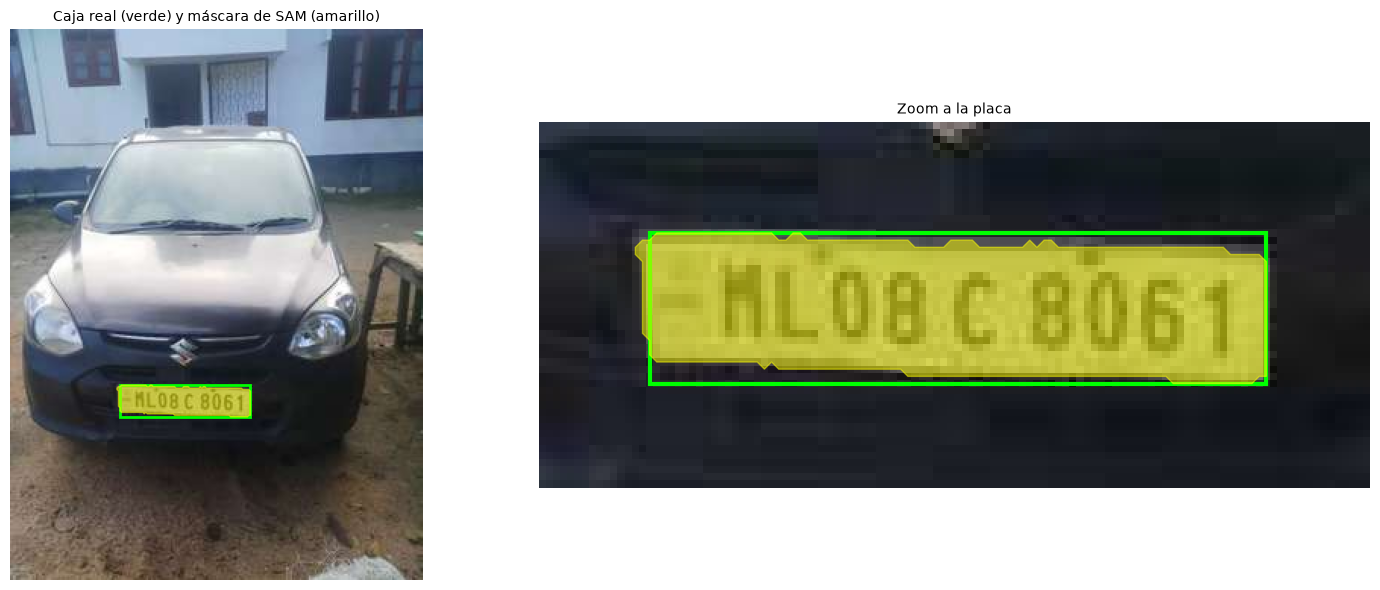

In [6]:
sam = SAM("sam2.1_t.pt")                       # se descarga la primera vez (~75 MB)

ruta_inclinada = DATA_DIR / "images" / "train" / "ML28.jpg"
caja = caja_real(ruta_inclinada)[0]            # la caja anotada por una persona
resultado_sam = sam(ruta_inclinada, bboxes=[caja.tolist()], device=DEVICE, verbose=False)[0]
poligono = resultado_sam.masks.xy[0]           # contorno de la placa, en píxeles

ancho, alto = Image.open(ruta_inclinada).size
mascara_placa = poligono_a_mascara(poligono, ancho, alto)
area_caja = (caja[2] - caja[0]) * (caja[3] - caja[1])
print(f"Área de la caja:    {area_caja:,.0f} píxeles")
print(f"Área de la máscara: {mascara_placa.sum():,} píxeles ({mascara_placa.sum() / area_caja:.0%} de la caja)")

x1, y1, x2, y2 = caja
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = mostrar(ruta_inclinada, "Caja real (verde) y máscara de SAM (amarillo)", ax=axes[0])
ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", lw=2))
ax.fill(poligono[:, 0], poligono[:, 1], color="yellow", alpha=0.5)

margen = 15
ax = mostrar(Image.open(ruta_inclinada).crop((x1 - margen, y1 - margen, x2 + margen, y2 + margen)), "Zoom a la placa", ax=axes[1])
ax.add_patch(plt.Rectangle((margen, margen), x2 - x1, y2 - y1, fill=False, edgecolor="lime", lw=3))
ax.fill(poligono[:, 0] - x1 + margen, poligono[:, 1] - y1 + margen, color="yellow", alpha=0.5)
plt.tight_layout()
plt.show()

### ¿Qué observamos?

Aquí se ve la gran diferencia entre caja y máscara. La placa está inclinada, así que la caja (verde) incluye **mucho fondo**: la placa ocupa menos de la mitad de la caja. La máscara de SAM (amarillo) sigue el **contorno real** de la placa.

Para anonimizar una placa, medir su tamaño real o leerla con un OCR, la máscara es mucho más precisa.

## 5. Construir el dataset de segmentación (auto-etiquetado)

### Las 4 clases

| Número | Clase | Viene de |
|--------|-------|----------|
| 0 | `license_plate` | SAM + caja real |
| 1 | `vehicle` | `car`, `truck` y `bus` de COCO (los unimos: en estas fotos, el modelo de COCO a veces llama "truck" a una camioneta) |
| 2 | `motorcycle` | `motorcycle` de COCO |
| 3 | `person` | `person` de COCO |

Como "profesor" para las clases de COCO usamos `yolo26m-seg` (*medium*), más grande y preciso que el *nano* que vamos a entrenar. Solo aceptamos sus máscaras con confianza de al menos 0.5.

### El formato YOLO de segmentación

Es igual al de detección, pero en lugar de una caja cada línea tiene el **polígono** del contorno, con las coordenadas normalizadas entre 0 y 1:

```
<clase> x1 y1 x2 y2 x3 y3 ... xn yn
```

Por ejemplo: `0 0.412 0.703 0.598 0.689 0.601 0.745 0.415 0.760` es una placa de 4 esquinas.

In [7]:
CLASES = {0: "license_plate", 1: "vehicle", 2: "motorcycle", 3: "person"}
COCO_A_NUESTRAS = {"car": 1, "truck": 1, "bus": 1, "motorcycle": 2, "person": 3}
CONF_PROFESOR = 0.5

profesor = YOLO("yolo26m-seg.pt")     # modelo de COCO más grande (~50 MB), solo para etiquetar


def linea_yolo(clase, poligono_normalizado):
    # Una línea del .txt: clase seguida de las coordenadas x y del polígono (entre 0 y 1).
    coordenadas = " ".join(f"{v:.5f}" for v in poligono_normalizado.reshape(-1))
    return f"{clase} {coordenadas}"


def etiquetar(ruta_img):
    # Devuelve las líneas del .txt de segmentación de una imagen.
    lineas = []

    # 1. Placas: SAM dibuja la máscara a partir de cada caja real
    cajas = caja_real(ruta_img)
    resultado = sam(ruta_img, bboxes=cajas.tolist(), device=DEVICE, verbose=False)[0]
    for poligono in resultado.masks.xyn:
        if len(poligono) >= 3:                        # un polígono necesita al menos 3 puntos
            lineas.append(linea_yolo(0, poligono))

    # 2. Vehículos, motos y personas: el modelo profesor de COCO
    resultado = profesor.predict(ruta_img, conf=CONF_PROFESOR, device=DEVICE, verbose=False)[0]
    if resultado.masks is not None:
        for clase_coco, poligono in zip(resultado.boxes.cls, resultado.masks.xyn):
            nombre = resultado.names[int(clase_coco)]
            if nombre in COCO_A_NUESTRAS and len(poligono) >= 3:
                lineas.append(linea_yolo(COCO_A_NUESTRAS[nombre], poligono))
    return lineas


# Probamos con la imagen de la placa inclinada
for linea in etiquetar(ruta_inclinada):
    valores = linea.split()
    print(f"clase {valores[0]} ({CLASES[int(valores[0])]}): {(len(valores) - 1) // 2} puntos → {' '.join(valores[:7])} ...")

clase 0 (license_plate): 43 puntos → 0 0.26838 0.64463 0.26471 0.64738 0.26103 0.64738 ...
clase 1 (vehicle): 491 puntos → 1 0.35658 0.17656 0.35449 0.17813 0.33990 0.17813 ...


Ahora aplicamos `etiquetar()` a **todas** las imágenes y guardamos el nuevo dataset en `SEG_DIR`, con la misma estructura que el original:

```
license-plates-seg/
├── images/train, images/val   ← copias de las fotos
└── labels/train, labels/val   ← los nuevos .txt con polígonos
```

**Tiempo estimado:** unos 3 minutos en una Mac con chip M3 (SAM + profesor, ~0.1 s por imagen). Si el dataset ya existe, la celda no lo vuelve a generar; pon `REGENERAR = True` para forzarlo.

In [8]:
REGENERAR = True

if (SEG_DIR / "labels" / "val").exists() and not REGENERAR:
    print(f"El dataset de segmentación ya existe en {SEG_DIR}")
else:
    inicio = time.time()
    for split, imagenes in [("train", imgs_train), ("val", imgs_val)]:
        (SEG_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (SEG_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)
        for i, ruta in enumerate(imagenes, start=1):
            shutil.copy(ruta, SEG_DIR / "images" / split / ruta.name)
            (SEG_DIR / "labels" / split / f"{ruta.stem}.txt").write_text("\n".join(etiquetar(ruta)))
            if i % 250 == 0 or i == len(imagenes):
                print(f"  {split}: {i}/{len(imagenes)} imágenes ({(time.time() - inicio) / 60:.1f} min)")
    print(f"Dataset creado en {(time.time() - inicio) / 60:.1f} minutos")

  train: 250/1526 imágenes (1.1 min)
  train: 500/1526 imágenes (2.2 min)
  train: 750/1526 imágenes (3.3 min)
  train: 1000/1526 imágenes (4.4 min)
  train: 1250/1526 imágenes (5.6 min)
  train: 1500/1526 imágenes (6.8 min)
  train: 1526/1526 imágenes (6.9 min)
  val: 169/169 imágenes (7.7 min)
Dataset creado en 7.7 minutos


### Revisemos las etiquetas generadas

Nunca hay que confiar a ciegas en un auto-etiquetado. Dibujamos los polígonos de algunas imágenes, **leyéndolos desde los `.txt`** que acabamos de escribir:

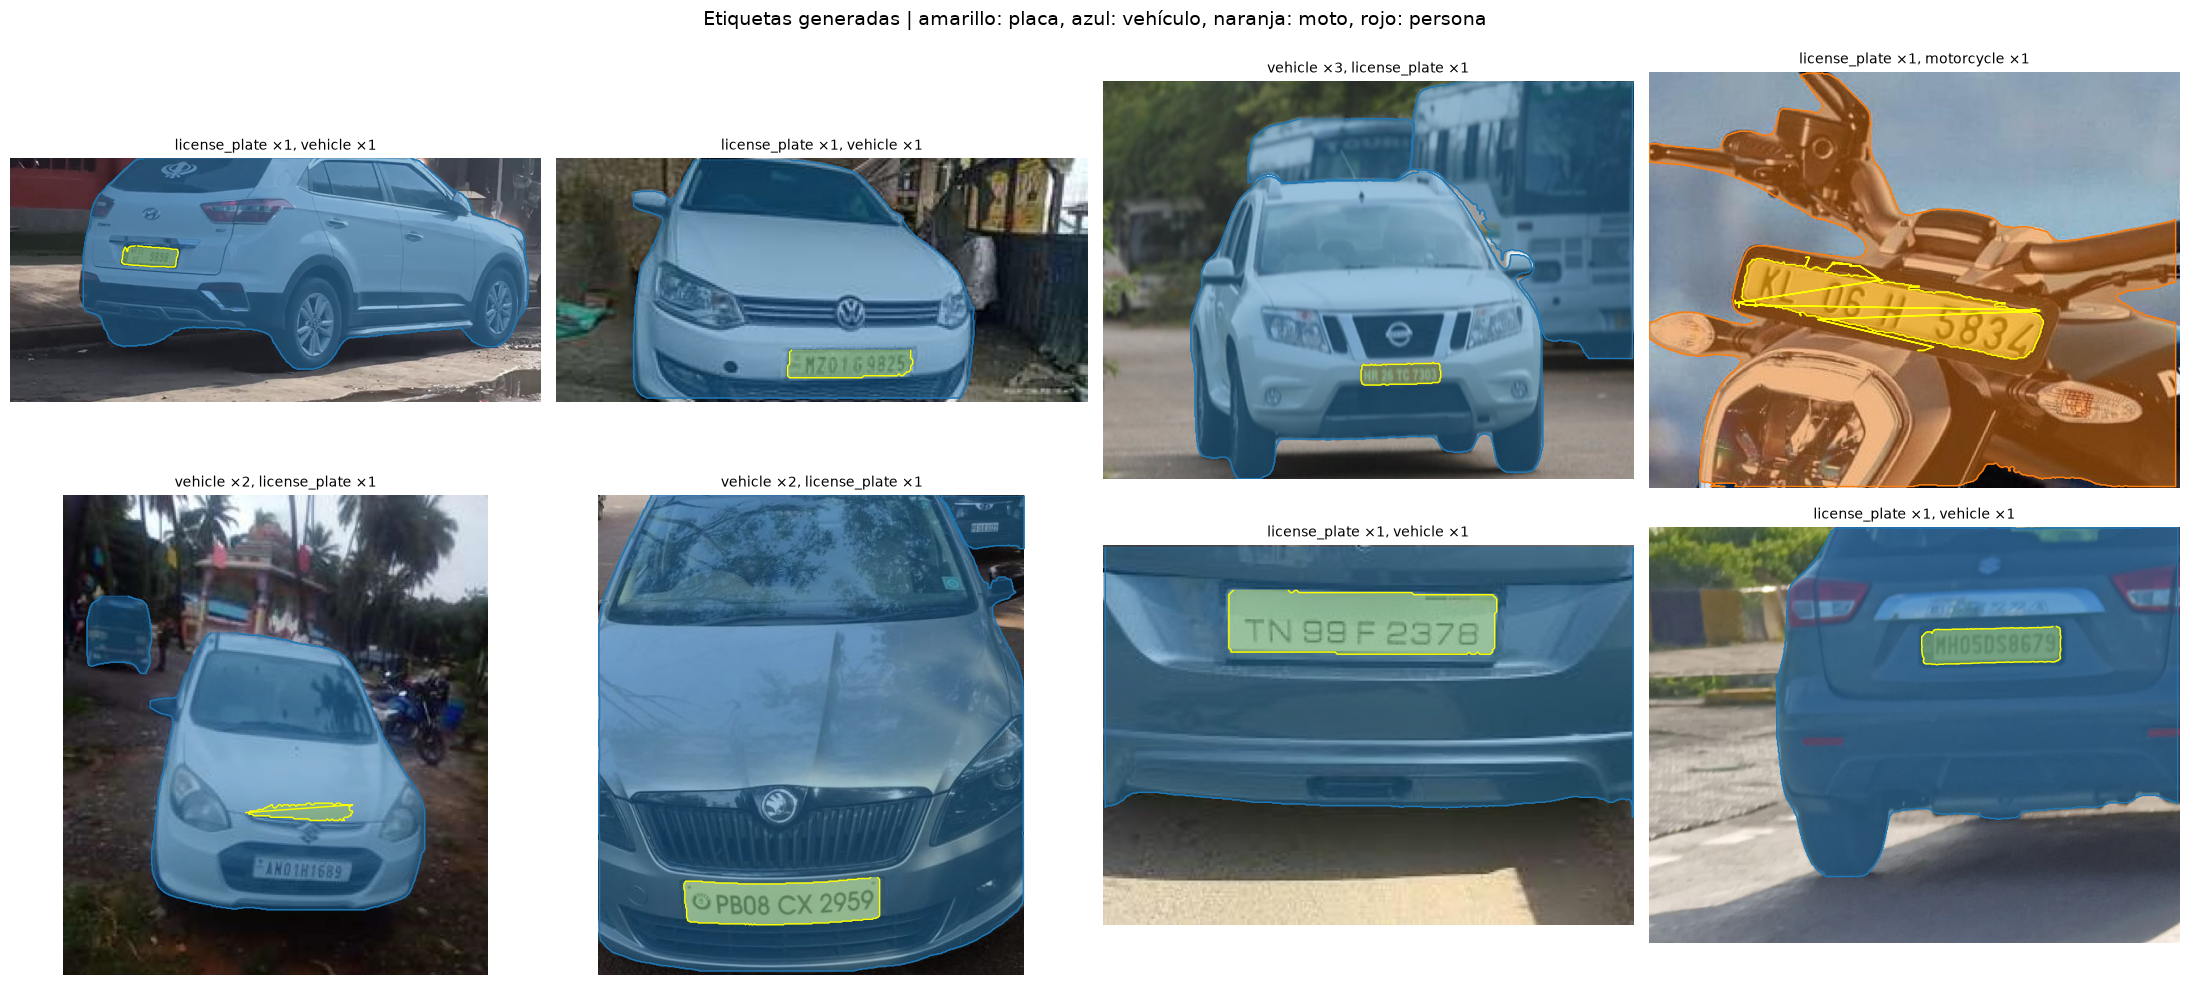

In [10]:
COLORES = {0: "yellow", 1: "tab:blue", 2: "tab:orange", 3: "tab:red"}


def leer_poligonos(ruta_txt):
    # Lee un .txt de segmentación → lista de (clase, polígono normalizado [n, 2]).
    poligonos = []
    for linea in Path(ruta_txt).read_text().splitlines():
        valores = np.array(linea.split(), dtype=float)
        poligonos.append((int(valores[0]), valores[1:].reshape(-1, 2)))
    return poligonos


def dibujar_poligonos(ax, ruta_img, poligonos, titulo=None):
    # Dibuja los polígonos (coordenadas normalizadas) rellenos sobre la imagen.
    imagen = Image.open(ruta_img)
    ancho, alto = imagen.size
    mostrar(imagen, titulo, ax=ax)
    for clase, poligono in poligonos:
        ax.fill(poligono[:, 0] * ancho, poligono[:, 1] * alto, color=COLORES[clase], alpha=0.45)
        ax.plot(poligono[:, 0] * ancho, poligono[:, 1] * alto, color=COLORES[clase], lw=1)


imgs_seg_train = sorted((SEG_DIR / "images" / "train").glob("*.jpg"))

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for ax, ruta in zip(axes.flat, random.sample(imgs_seg_train, 8)):
    poligonos = leer_poligonos(SEG_DIR / "labels" / "train" / f"{ruta.stem}.txt")
    conteo = pd.Series([CLASES[c] for c, _ in poligonos]).value_counts()
    dibujar_poligonos(ax, ruta, poligonos, ", ".join(f"{n} ×{k}" for n, k in conteo.items()))
plt.suptitle("Etiquetas generadas | amarillo: placa, azul: vehículo, naranja: moto, rojo: persona", fontsize=14)
plt.tight_layout()
plt.show()

Contemos cuántos objetos de cada clase tiene el nuevo dataset:

In [11]:
filas = []
for split in ["train", "val"]:
    for ruta_txt in sorted((SEG_DIR / "labels" / split).glob("*.txt")):
        for clase, poligono in leer_poligonos(ruta_txt):
            filas.append({"split": split, "imagen": ruta_txt.stem, "clase": CLASES[clase], "puntos": len(poligono)})

df_etiquetas = pd.DataFrame(filas)
resumen = pd.crosstab(df_etiquetas["clase"], df_etiquetas["split"])
resumen["imágenes con la clase"] = df_etiquetas.groupby("clase")["imagen"].nunique()
resumen.loc[list(CLASES.values())]

split,train,val,imágenes con la clase
clase,,,
license_plate,1525,169,1694
vehicle,2031,207,1547
motorcycle,77,5,72
person,254,27,204


### ¿Qué observamos?

- Hay **una placa por imagen** (vienen de las cajas reales) y **vehículos en la gran mayoría** de las fotos.
- Motos y personas aparecen en **pocas** imágenes: son clases **minoritarias**. Esperemos que el modelo las aprenda peor.

### Una advertencia importante

Estas etiquetas **no son perfectas**: las generó un modelo, no una persona. Las de placas son bastante confiables (SAM parte de cajas anotadas por humanos), pero las de vehículos, motos y personas heredan los errores del profesor: objetos que no vio, máscaras incompletas o clases confundidas.

Además, las etiquetas de **validación** también son automáticas. Por eso, las métricas que obtengamos medirán **qué tan bien imita nuestro modelo a sus profesores**, no su exactitud frente a la realidad. En un proyecto real, se revisaría y corregiría al menos la validación a mano (con herramientas como CVAT o Label Studio).

## 6. El archivo `data.yaml`

Igual que en detección: le decimos a Ultralytics dónde están las imágenes y cómo se llaman las clases. Ultralytics reconoce que es un dataset de segmentación porque las etiquetas tienen polígonos.

In [12]:
config = {
    "path": str(SEG_DIR),
    "train": "images/train",
    "val": "images/val",
    "names": CLASES,
}
DATA_YAML = SEG_DIR / "data.yaml"
DATA_YAML.write_text(yaml.safe_dump(config, sort_keys=False))
print(DATA_YAML.read_text())

path: C:\Users\SpideGamer\Documents\ciencia-de-datos-g8\01-python-intro\data\license-plates-seg
train: images/train
val: images/val
names:
  0: license_plate
  1: vehicle
  2: motorcycle
  3: person



## 7. Entrenamiento

Partimos de `yolo26n-seg.pt`, los pesos de segmentación entrenados en COCO (**transfer learning**). Ultralytics reemplaza la capa final para que prediga nuestras 4 clases en lugar de las 80 de COCO.

La llamada es la misma que en detección; solo cambia el modelo de partida:

| Parámetro | Valor | Significado |
|-----------|-------|-------------|
| `epochs` | 20 | Pasadas completas por el set de entrenamiento |
| `imgsz` | 640 | Tamaño al que se redimensionan las imágenes |
| `batch` | 16 | Imágenes por iteración (bájalo a 8 si te quedas sin memoria) |
| `patience` | 10 | Detiene el entrenamiento si el mAP no mejora en 10 épocas |

**Tiempo estimado:** unos 40 minutos en una Mac con chip M3 (~2 minutos por época), más del doble que la detección, porque además de las cajas aprende las máscaras. Para una prueba rápida, baja `EPOCHS` a 5. Si ya existe un modelo entrenado, la celda lo reutiliza; pon `ENTRENAR_DE_NUEVO = True` para forzarlo.

In [13]:
EPOCHS = 5
BATCH = 32
IMGSZ = 640
NOMBRE_RUN = "segmentacion_yolo26n"
ENTRENAR_DE_NUEVO = False

SAVE_DIR = RUNS_DIR / NOMBRE_RUN
BEST_PT = SAVE_DIR / "weights" / "best.pt"

if BEST_PT.exists() and not ENTRENAR_DE_NUEVO:
    print(f"Ya existe un modelo entrenado: {BEST_PT}")
else:
    modelo = YOLO("yolo26n-seg.pt")       # pesos de segmentación de COCO → transfer learning
    inicio = time.time()
    modelo.train(
        data=str(DATA_YAML),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        patience=10,
        device=DEVICE,
        seed=SEED,
        project=str(RUNS_DIR),
        name=NOMBRE_RUN,
        exist_ok=True,
        plots=True,
    )
    print(f"\nEntrenamiento completado en {(time.time() - inicio) / 60:.1f} minutos")

New https://pypi.org/project/ultralytics/8.4.171 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.170  Python-3.13.2 torch-2.14.0+cu132 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\SpideGamer\Documents\ciencia-de-datos-g8\01-python-intro\data\license-plates-seg\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0

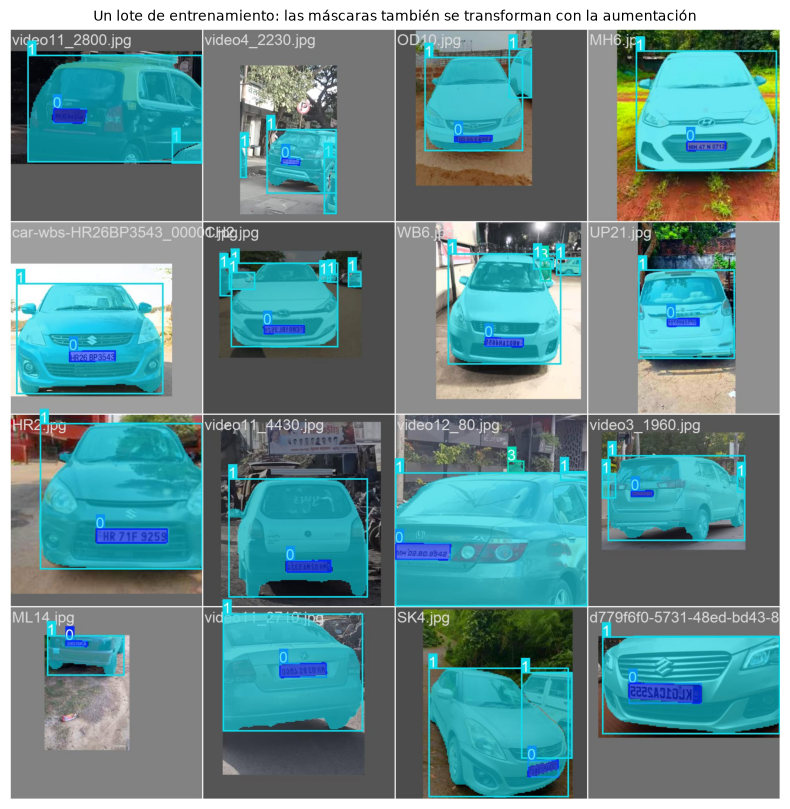

In [14]:
mostrar(SAVE_DIR / "train_batch0.jpg", "Un lote de entrenamiento: las máscaras también se transforman con la aumentación",
        figsize=(10, 10))
plt.show()

Igual que en detección, Ultralytics aplica la aumentación **mosaico**. Fíjate que las máscaras se recortan, escalan y voltean **junto con** las imágenes: si la foto se voltea, el polígono también.

## 8. Curvas de entrenamiento

Además de las pérdidas de detección (`box_loss`, `cls_loss`...), ahora aparece **`seg_loss`**: mide qué tan bien coincide la máscara predicha con la real, píxel a píxel. (YOLO26 registra también una `sem_loss`, una ayuda interna de segmentación semántica que usa durante el entrenamiento; no hace falta interpretarla.)

Y las métricas vienen en **dos versiones**:

- **(B)** de *box*: evalúa las **cajas**, como en detección.
- **(M)** de *mask*: evalúa las **máscaras**. Es más exigente, porque hay que acertar el contorno, no solo el rectángulo.

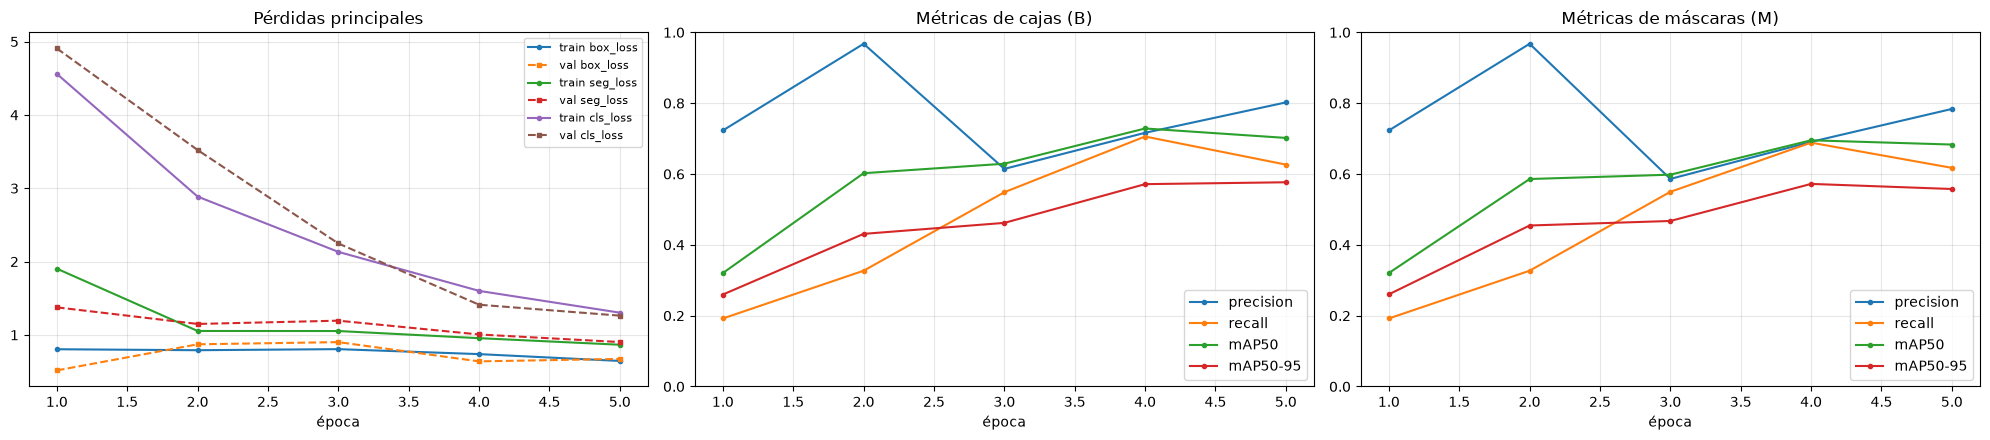

In [15]:
df_res = pd.read_csv(SAVE_DIR / "results.csv")
df_res.columns = df_res.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
for perdida, estilo in [("box_loss", "-"), ("seg_loss", "-"), ("cls_loss", "-")]:
    axes[0].plot(df_res["epoch"], df_res[f"train/{perdida}"], "o" + estilo, ms=3, label=f"train {perdida}")
    axes[0].plot(df_res["epoch"], df_res[f"val/{perdida}"], "s--", ms=3, label=f"val {perdida}")
axes[0].set(title="Pérdidas principales", xlabel="época")
axes[0].legend(fontsize=8)

for eje, tipo, titulo in [(axes[1], "B", "Métricas de cajas (B)"), (axes[2], "M", "Métricas de máscaras (M)")]:
    for metrica in ["precision", "recall", "mAP50", "mAP50-95"]:
        eje.plot(df_res["epoch"], df_res[f"metrics/{metrica}({tipo})"], "o-", ms=3, label=metrica)
    eje.set(title=titulo, xlabel="época", ylim=(0, 1))
    eje.legend()

for eje in axes:
    eje.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### ¿Qué observamos?

- Las pérdidas de **entrenamiento** bajan de forma constante.
- Las de **validación** oscilan y dejan de mejorar hacia la mitad del entrenamiento. Es esperable: la validación es pequeña (169 imágenes) y sus etiquetas son automáticas, así que es una medida "ruidosa".
- Aun así, el **mAP50-95 de máscaras sigue subiendo** hasta la última época (de ~0.4 a ~0.65): con más épocas, probablemente mejoraría un poco más.
- En general, las métricas de máscaras (M) quedan **por debajo** de las de cajas (B): segmentar bien el contorno es más difícil que encerrar el objeto en un rectángulo.

## 9. Evaluación

### IoU de máscaras

En detección calculábamos el IoU entre dos **cajas**. En segmentación se calcula entre dos **máscaras**, contando píxeles:

$$\text{IoU} = \frac{\text{píxeles en ambas máscaras}}{\text{píxeles en al menos una máscara}}$$

Con máscaras booleanas de NumPy es muy simple: la intersección es `m1 & m2` y la unión es `m1 | m2`.

In [16]:
def iou_mascaras(m1, m2):
    # IoU entre dos máscaras booleanas del mismo tamaño.
    union = np.logical_or(m1, m2).sum()
    return np.logical_and(m1, m2).sum() / union if union > 0 else 0.0


modelo_best = YOLO(BEST_PT)

# Placa inclinada: comparamos la máscara de SAM (etiqueta) con la que predice nuestro modelo
ancho, alto = Image.open(ruta_inclinada).size
resultado = modelo_best.predict(ruta_inclinada, conf=0.25, classes=[0], device=DEVICE, verbose=False)[0]
mascara_predicha = poligono_a_mascara(resultado.masks.xy[0], ancho, alto)

# La caja real, convertida en una máscara rectangular
x1, y1, x2, y2 = caja_real(ruta_inclinada)[0]
mascara_caja = poligono_a_mascara([(x1, y1), (x2, y1), (x2, y2), (x1, y2)], ancho, alto)

print(f"IoU(máscara predicha, máscara de SAM) = {iou_mascaras(mascara_predicha, mascara_placa):.3f}")
print(f"IoU(caja real,        máscara de SAM) = {iou_mascaras(mascara_caja, mascara_placa):.3f}")

IoU(máscara predicha, máscara de SAM) = 0.909
IoU(caja real,        máscara de SAM) = 0.857


El segundo número es revelador: si usáramos la **caja** como si fuera la máscara de esta placa inclinada, el IoU sería bajo, porque la caja incluye mucho fondo. El modelo de segmentación, en cambio, reproduce la forma real de la placa.

### Métricas en validación

`modelo.val()` calcula precisión, recall y mAP **para cajas y para máscaras**, por clase:

In [17]:
metricas_val = modelo_best.val(data=str(DATA_YAML), split="val", imgsz=IMGSZ, batch=BATCH, device=DEVICE,
                               project=str(RUNS_DIR), name="segmentacion_val", exist_ok=True, verbose=False)

instancias_val = df_etiquetas[df_etiquetas["split"] == "val"]["clase"].value_counts()
filas = []
for i, clase in enumerate(metricas_val.box.ap_class_index):
    nombre = CLASES[int(clase)]
    _, _, ap50_caja, ap_caja = metricas_val.box.class_result(i)
    _, _, ap50_mascara, ap_mascara = metricas_val.seg.class_result(i)
    filas.append({"clase": nombre, "objetos en val": instancias_val.get(nombre, 0),
                  "mAP50-95 caja": ap_caja, "mAP50-95 máscara": ap_mascara, "mAP50 máscara": ap50_mascara})
filas.append({"clase": "TODAS", "objetos en val": instancias_val.sum(),
              "mAP50-95 caja": metricas_val.box.map, "mAP50-95 máscara": metricas_val.seg.map,
              "mAP50 máscara": metricas_val.seg.map50})
pd.DataFrame(filas).set_index("clase").round(3)

Ultralytics 8.4.170  Python-3.13.2 torch-2.14.0+cu132 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO26n-seg summary (fused): 136 layers, 2,689,664 parameters, 0 gradients, 9.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 459.7245.8 MB/s, size: 138.3 KB)
val: Scanning C:\Users\SpideGamer\Documents\ciencia-de-datos-g8\01-python-intro\data\license-plates-seg\labels\val.cache... 169 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 169/169 47.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 5.4s/it 32.2s1.3ss
                   all        169        408      0.689      0.729      0.733      0.559       0.68      0.721      0.715      0.564
Speed: 3.2ms preprocess, 6.6ms inference, 0.0ms loss, 7.4ms postprocess per image
Results saved to C:\Users\SpideGamer\Documents\ciencia-de-datos-g8\01-python-intro\notebooks\runs\segmentacion_val


,objetos en val,mAP50-95 caja,mAP50-95 máscara,mAP50 máscara
clase,,,,
license_plate,169,0.877,0.859,0.994
vehicle,207,0.788,0.797,0.913
motorcycle,5,0.171,0.239,0.333
person,27,0.401,0.363,0.620
TODAS,408,0.559,0.564,0.715


### ¿Cómo leer esta tabla?

- **mAP50-95 máscara** es la métrica principal: exige que el contorno coincida con la etiqueta a distintos niveles de IoU (de 0.50 a 0.95).
- **Placas y vehículos** (las clases con muchos ejemplos) superan 0.8: el modelo las segmenta bien.
- En las placas, el mAP50 es casi perfecto pero el mAP50-95 baja: encontrar la placa es fácil; ajustar su contorno al píxel en un objeto tan pequeño es lo difícil.
- **Motos y personas** quedan mucho más bajas. Compara con su número de **objetos en validación**: con solo 5 motos y 27 personas, unas pocas imágenes deciden el resultado, y además el modelo vio pocos ejemplos al entrenar. Es el problema de las **clases minoritarias**.
- Recuerda que estas métricas comparan contra etiquetas **automáticas**: miden cuánto se parece nuestro modelo a sus profesores.

## 10. Predicciones del modelo entrenado

Comparamos, en imágenes de validación, las **etiquetas** (arriba) con las **predicciones** del modelo (abajo):

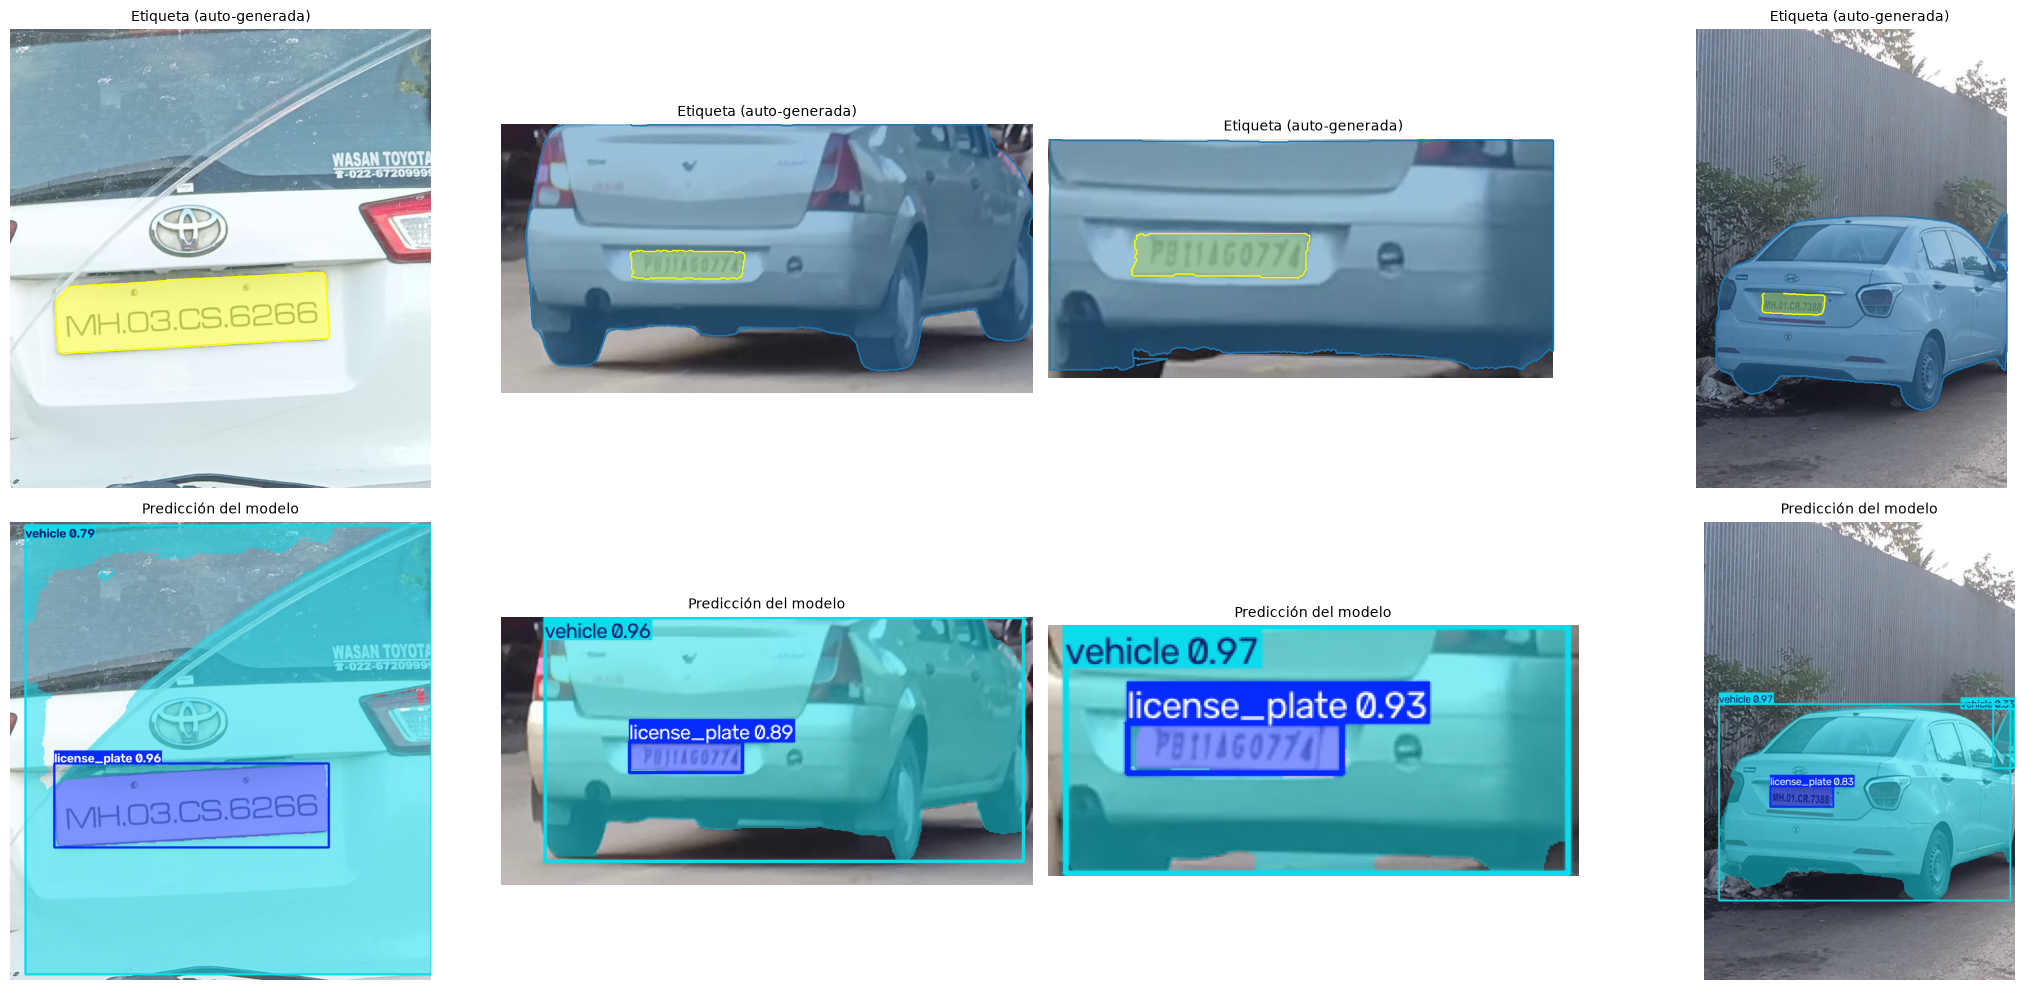

In [18]:
muestra = random.sample(sorted((SEG_DIR / "images" / "val").glob("*.jpg")), 4)

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for col, ruta in enumerate(muestra):
    poligonos = leer_poligonos(SEG_DIR / "labels" / "val" / f"{ruta.stem}.txt")
    dibujar_poligonos(axes[0, col], ruta, poligonos, "Etiqueta (auto-generada)")
    resultado = modelo_best.predict(ruta, conf=0.25, device=DEVICE, verbose=False)[0]
    mostrar(resultado.plot()[..., ::-1], "Predicción del modelo", ax=axes[1, col])
plt.tight_layout()
plt.show()

### ¿Qué observamos?

- Un solo modelo, en **una sola pasada**, segmenta a la vez la placa, el vehículo y, si aparecen, motos y personas.
- A veces el modelo encuentra objetos que la etiqueta **no tenía**, por ejemplo autos parcialmente visibles en los bordes de la foto. El profesor los descartó (confianza menor a 0.5), pero nuestro modelo sí los segmenta. En las métricas cuentan como **falsos positivos**, aunque sean correctos: otra consecuencia de evaluar contra etiquetas automáticas.

## 11. Aplicaciones: ¿para qué sirve una máscara?

### Anonimizar placas

Una placa es un **dato personal**: permite identificar al dueño del vehículo. Antes de publicar fotos o videos de la calle (por ejemplo, en mapas o redes sociales) se suelen **difuminar**.

Con la máscara difuminamos **solo los píxeles de la placa**, sin tocar el resto del auto:

1. Creamos una versión difuminada de toda la imagen.
2. Combinamos: donde la máscara vale 1 usamos la versión difuminada; donde vale 0, la original (`Image.composite`).

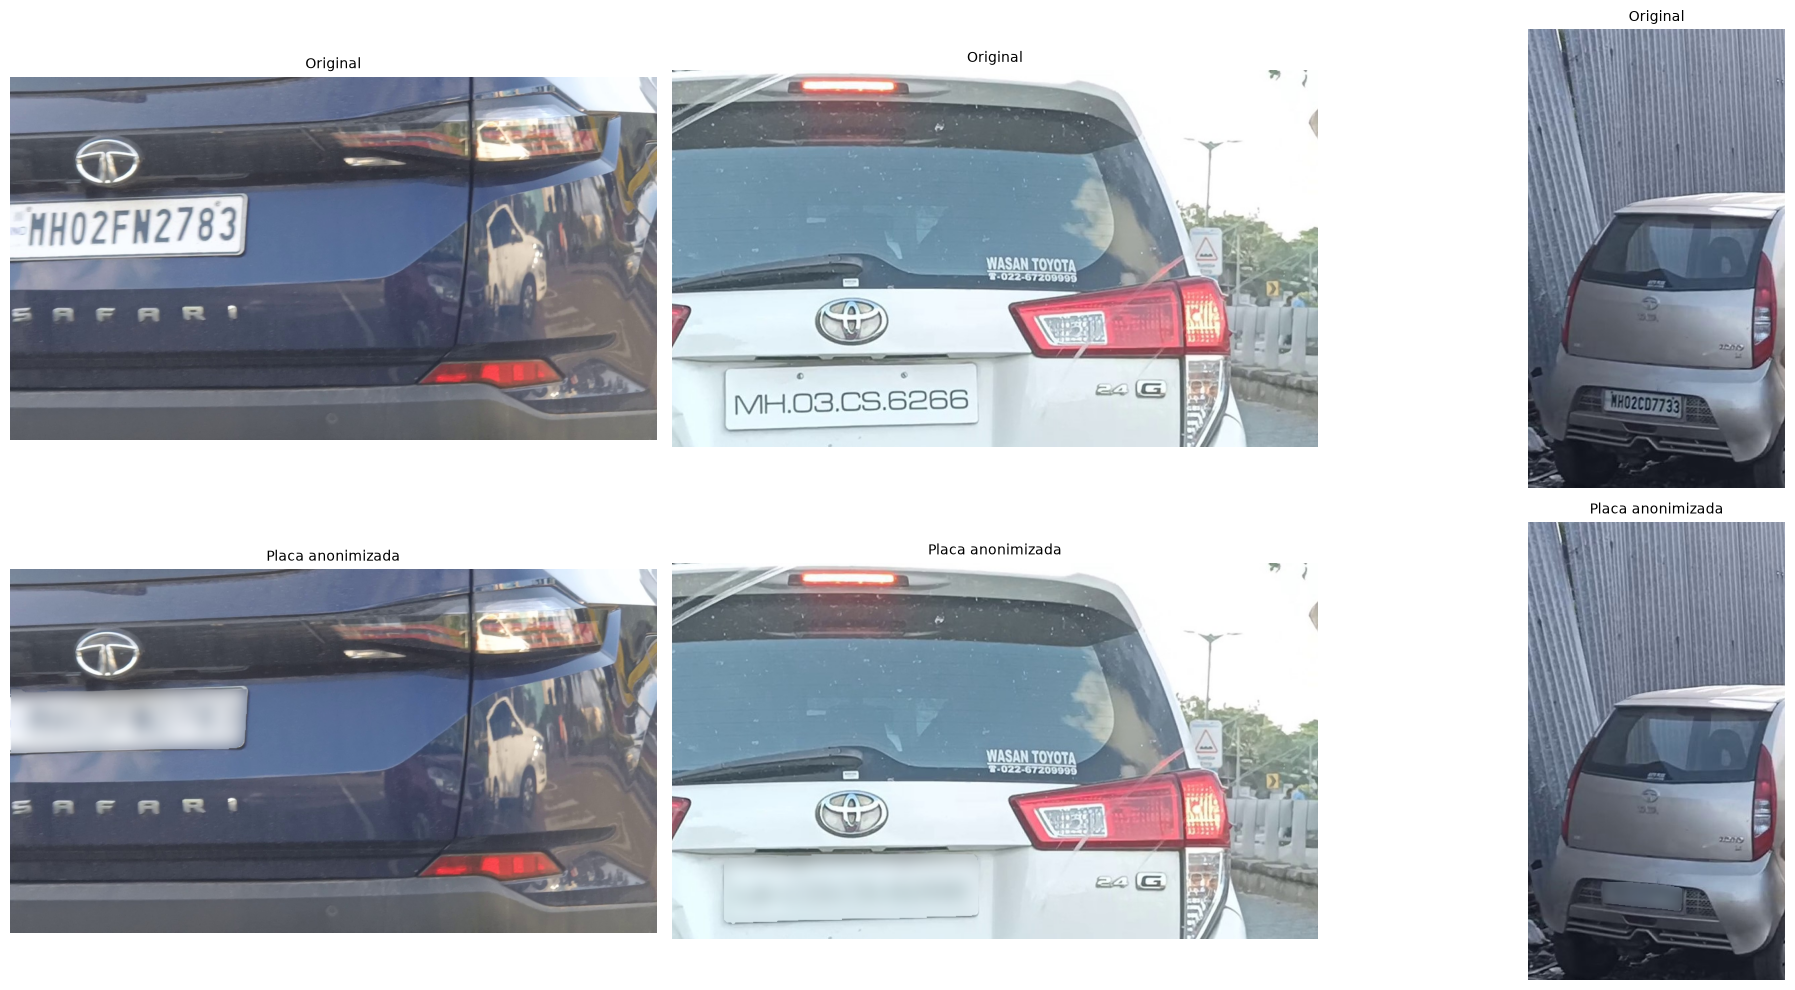

In [19]:
def mascara_de_clase(resultado, clase, ancho, alto):
    # Une en una sola máscara todos los objetos de una clase.
    mascara = np.zeros((alto, ancho), dtype=bool)
    if resultado.masks is not None:
        for c, poligono in zip(resultado.boxes.cls, resultado.masks.xy):
            if int(c) == clase and len(poligono) >= 3:
                mascara |= poligono_a_mascara(poligono, ancho, alto)
    return mascara


def anonimizar_placas(ruta_img, modelo=modelo_best, conf=0.25):
    # Difumina solo los píxeles de las placas detectadas.
    imagen = Image.open(ruta_img).convert("RGB")
    resultado = modelo.predict(imagen, conf=conf, device=DEVICE, verbose=False)[0]
    mascara = mascara_de_clase(resultado, 0, *imagen.size)
    difuminada = imagen.filter(ImageFilter.GaussianBlur(radius=max(imagen.size) / 80))
    return Image.composite(difuminada, imagen, Image.fromarray(mascara.astype(np.uint8) * 255))


fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for col, ruta in enumerate(random.sample(imgs_val, 3)):
    mostrar(ruta, "Original", ax=axes[0, col])
    mostrar(anonimizar_placas(ruta), "Placa anonimizada", ax=axes[1, col])
plt.tight_layout()
plt.show()

### Recortar un vehículo sin fondo

Con la máscara de la clase `vehicle` podemos separar el auto del fondo, por ejemplo para un catálogo de venta de autos:

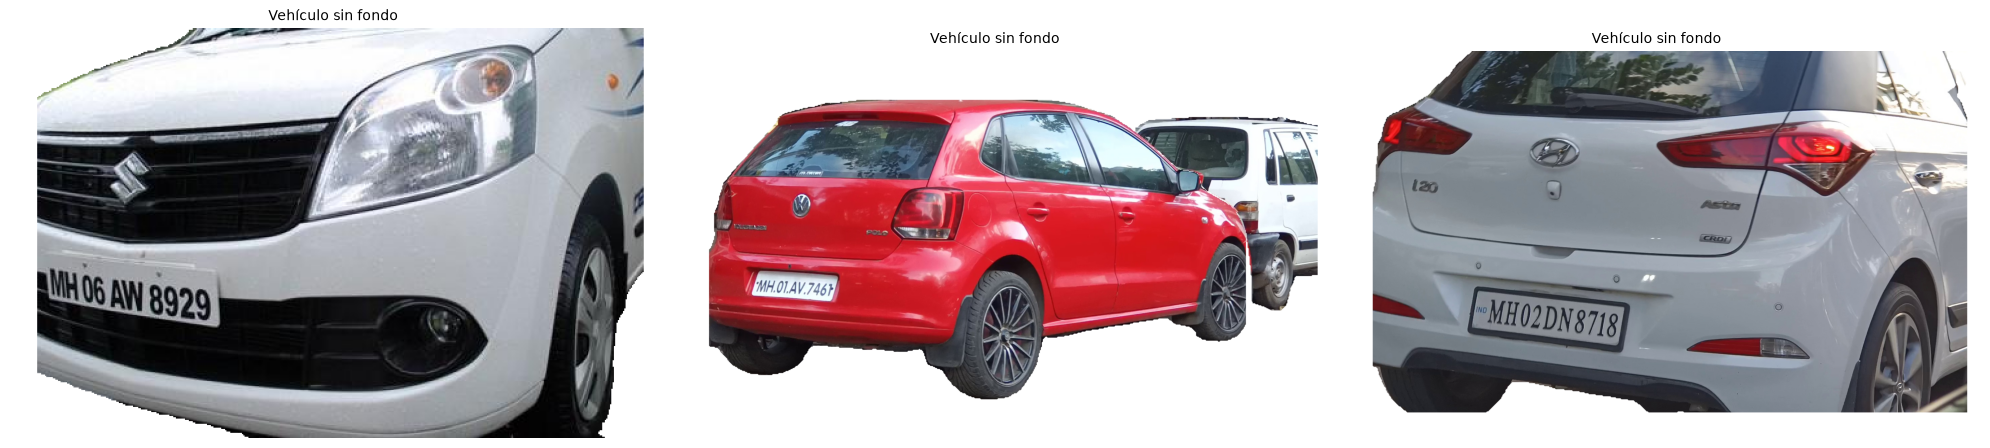

In [20]:
def recortar_vehiculo(ruta_img, modelo=modelo_best, conf=0.25):
    # Devuelve la imagen con fondo blanco, conservando solo los vehículos.
    imagen = Image.open(ruta_img).convert("RGB")
    resultado = modelo.predict(imagen, conf=conf, device=DEVICE, verbose=False)[0]
    mascara = mascara_de_clase(resultado, 1, *imagen.size)
    fondo = Image.new("RGB", imagen.size, (255, 255, 255))
    return Image.composite(imagen, fondo, Image.fromarray(mascara.astype(np.uint8) * 255))


fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, ruta in zip(axes, random.sample(imgs_train, 3)):
    mostrar(recortar_vehiculo(ruta), "Vehículo sin fondo", ax=ax)
plt.tight_layout()
plt.show()

Ninguna de estas dos aplicaciones se puede hacer bien con una **caja**: difuminar la caja borraría también parte del parachoques, y recortar la caja dejaría el fondo alrededor del auto.